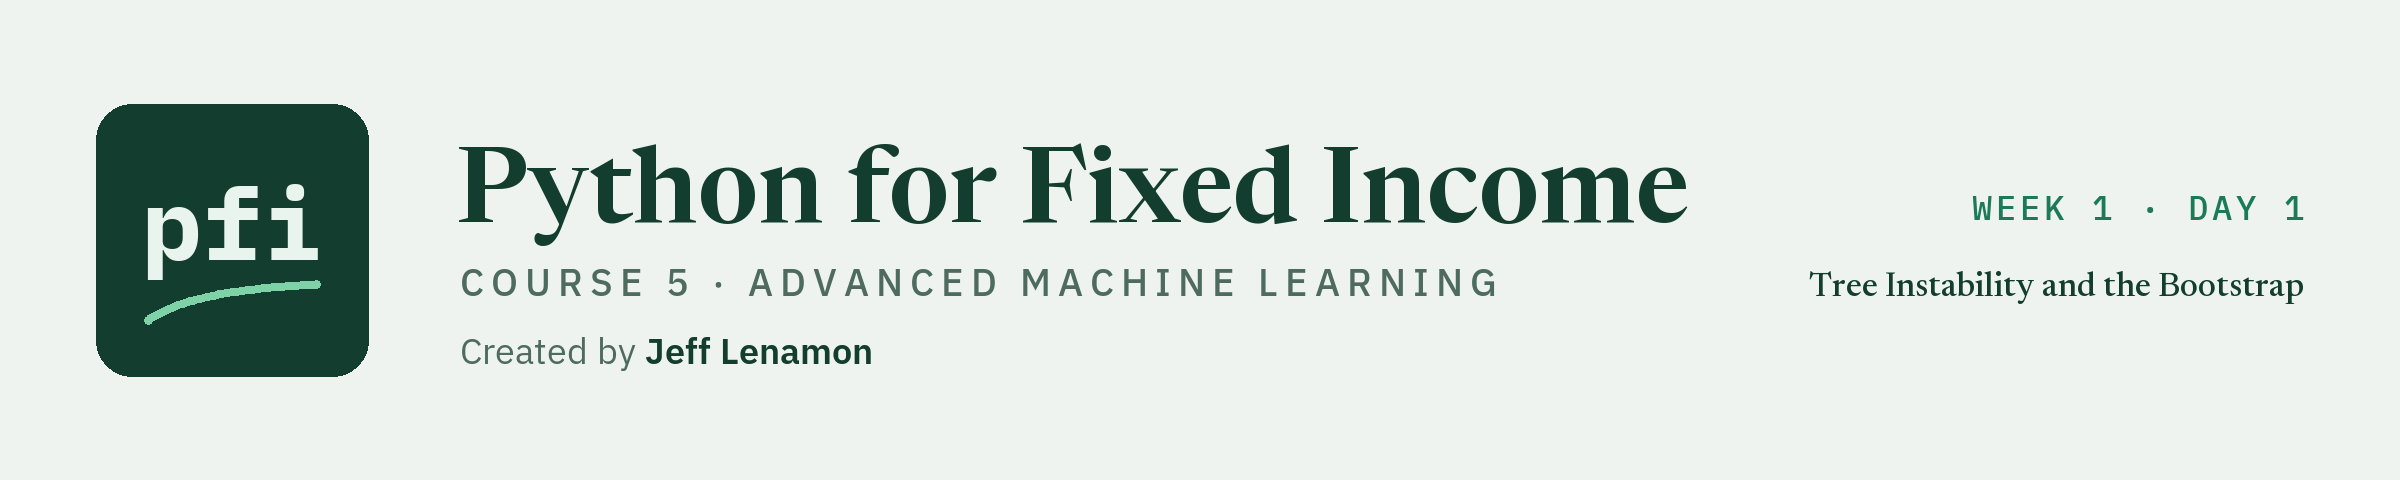

# Tree Instability and the Bootstrap

Week 1, Day 1. One tree fitted to slightly different rows gives a different tree. Today: how much of a tree's output on an account comes from which rows it happened to see, the bootstrap that makes new samples from one set of rows, and the first sign that averaging trees helps.

**Data:** `credit_card_default.csv`, 30,000 card accounts in Taiwan in 2005: **real**, UCI Machine Learning Repository dataset 350, CC BY 4.0. Citation: Yeh, I. (2009). Default of Credit Card Clients [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C55S3H.

> This course is educational content created in a personal capacity. Nothing here is investment advice or a recommendation to buy or sell any security. All portfolio data is synthetic.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lenamonj/python-fixed-income/blob/main/course5_advanced_ml/week1/day1/01_tree_instability_and_the_bootstrap.ipynb)

Course 4 ended week 2 with decision trees on the card file. A tree grown with the default settings fitted its training rows almost perfectly and did much worse on rows it never saw; pruning reined it in. Course 5 starts from that tree and asks a different question: **if the training rows had been slightly different, how different would the tree be?** The answer is the reason for this whole week. A tree is unstable, and an average of many unstable trees is not.

To ask the question you need many sets of training rows, and you have one. The **bootstrap** makes new ones from it: draw rows at random, with replacement, as many as there are. Each draw is a plausible other training set, and the rows it leaves out are a free test of whatever was fitted on it.

**The card rules, as on every card day in this course.**

* **The data is real.** `credit_card_default.csv` is the UCI file Course 1 described in notebook 16 and Course 4 modelled in week 2: 30,000 credit card accounts with payment records from April to September 2005 and an outcome for the following month. The accounts are in Taiwan in 2005, and consumer credit there differs from US credit. Nothing here describes any other market.
* **People's attributes are never features.** The file has four columns that describe people: `SEX`, `EDUCATION`, `MARRIAGE`, and `AGE`. No model in this course uses them, and no output is grouped by them. Every model today uses the other 19 columns, Course 4's.
* **Course 4's split, rebuilt.** 18,000 training rows fit, 6,000 validation rows report, and Course 4's 6,000 test rows stay closed for the whole course (section 1.2).
* **A model's output is described, never acted on.** A tree's output is the model probability of default in this file, or a flag at a threshold; a tree fitted with class weights gives the model's score. No output of either kind is a credit decision for any person, and no tree's questions are a rule for lending.

Today you will:

1. Recompute where Course 4 left the tree: its default tree and its pruned tree on the same rows.
2. State the rows line and the test-row rule, once for the whole course, and test them.
3. Draw a bootstrap sample with `bootstrap_positions` and count what it leaves out.
4. Fit ten full trees on ten bootstrap samples and see what moves and what does not.
5. Follow one account through the ten trees.
6. Do the same with depth-3 trees: steadier, and weaker.
7. Average the ten full trees, the idea of week 1.
8. Name the out-of-bag rows with `out_of_bag`, for day 2.

Q. Set up today's work folder: the thread settings, the seed, and the card file.

In [1]:
# today's setup: the thread settings, the modules, the seed, the course data, and a fresh work folder
import os

# one thread for the maths libraries, so every run of the notebook gives the same last digits.
# These two lines must run before numpy, pandas, scikit-learn, XGBoost, or LightGBM is imported: if you ran another
# cell first, restart the kernel and run this cell first (in Colab: Runtime, Restart session).
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"

import importlib
import importlib.metadata
import importlib.util
import platform
import shutil
import subprocess
import sys
import tempfile
import urllib.request
from pathlib import Path

# packages a Colab runtime or a new environment may lack: stop with the line that installs the missing one
for module_name, install_name in [("sklearn", "scikit-learn"), ("statsmodels", "statsmodels"), ("scipy", "scipy"), ("xgboost", "xgboost"), ("lightgbm", "lightgbm"), ("imblearn", "imbalanced-learn"), ("shap", "shap"), ("pytest", "pytest")]:
    if importlib.util.find_spec(module_name) is None:
        raise RuntimeError(f"{install_name} is not installed. Run  !pip install {install_name}  in a new cell, "
                           "then run this cell again.")

import numpy as np
import pandas as pd

# the versions the saved outputs of this notebook came from (course5_advanced_ml/requirements.txt)
PINNED = {"numpy": "2.5.3", "pandas": "3.0.6", "scikit-learn": "1.9.1", "scipy": "1.18.1", "xgboost": "3.4.1", "lightgbm": "4.7.0", "imbalanced-learn": "0.14.2", "shap": "0.52.0", "matplotlib": "3.11.2", "pytest": "9.1.1"}
installed = {name: importlib.metadata.version(name) for name in PINNED}
print(f"Python {platform.python_version()}; " + ", ".join(f"{name} {version}" for name, version in installed.items()))
different = [name for name in PINNED if installed[name] != PINNED[name]]
if different:
    print(f"Not the course's pinned version: {', '.join(different)}. Printed numbers may differ in the last digits from the saved notebook.")

# the seed: one number for every random choice the course makes, so every run makes the same choices
SEED = 42

# remember the notebook's own folder, so that running this cell again starts from the same place
if "notebook_folder" not in globals():
    notebook_folder = Path.cwd()

# 1. find the course data before moving: the repo's data folder on your machine, GitHub in Colab
RAW_DATA = "https://raw.githubusercontent.com/lenamonj/python-fixed-income/main/data/"
local_data = (notebook_folder / ".." / ".." / ".." / "data").resolve()
on_github = not (local_data / "credit_card_default.csv").exists()

# 2. a fresh work folder for today, in the system temp folder, outside the course repo
work = Path(tempfile.mkdtemp(prefix="pfi_course5_01_"))
os.chdir(work)

# 3. copy today's data files into the work folder
DATA_FILES = ["credit_card_default.csv"]
for name in DATA_FILES:
    if on_github:
        urllib.request.urlretrieve(RAW_DATA + name, work / name)
    else:
        shutil.copy(local_data / name, work / name)

# print the folder's name only: its full path would show your user name
print(f"Work folder: {work.name}, in your temp folder")
print(f"Data files from {'GitHub' if on_github else 'the data folder of the course repo'}: {', '.join(DATA_FILES)}")
print(f"SEED = {SEED}")

Python 3.13.8; numpy 2.5.3, pandas 3.0.6, scikit-learn 1.9.1, scipy 1.18.1, xgboost 3.4.1, lightgbm 4.7.0, imbalanced-learn 0.14.2, shap 0.52.0, matplotlib 3.11.2, pytest 9.1.1
Work folder: pfi_course5_01_az141ygt, in your temp folder
Data files from the data folder of the course repo: credit_card_default.csv
SEED = 42


* The first lines set two thread settings **before** numpy, pandas, or scikit-learn is imported, as in Course 4. Course 5 adds XGBoost and LightGBM in week 2, which use every core unless told otherwise, so from today every model call that can take `n_jobs` is written with `n_jobs=1`, and the version line shows the four new libraries.
* The setup checks that every Course 5 library is installed without importing it, so a missing one stops here with the line that installs it.
* `SEED = 42` is the course's one seed, as in Course 4.

Q. Write `mlkit.py`, Course 4's complete module, unchanged. `ensemblekit` imports it.

In [2]:
%%writefile mlkit.py
"""mlkit: the small pieces of machine learning that scikit-learn leaves to the analyst, written down and tested.

Written day by day in Python for Fixed Income, Course 4: Machine Learning.

Conventions, the same in every function:
- The seed is 42 wherever a function takes one, so every run gives the same numbers.
- Spreads are in basis points (bp). A model of log_oas is fitted in natural logs of bp; its errors are reported
  in bp after exp, and exp of a fitted log is a median-type value, not a mean.
- The positive class is 1 (default, bankrupt). Precision, recall, and F1 are for class 1 only.
- A row is flagged when its model probability is at least the threshold (probability >= threshold).
- Rows that fit a model, rows that choose a setting, and rows that report a result are kept apart; the split
  functions here prove it with a check that stops.
- Inputs of the wrong shape, or empty inputs, raise ValueError with a message that says what was wrong.
"""
import numpy as np  # arrays and arithmetic
import pandas as pd  # tables with labels
from numpy.typing import ArrayLike  # a list, an array, or a pandas Series


def assert_disjoint(train_index: ArrayLike, test_index: ArrayLike) -> None:
    """Stop if any row label is in both the training rows and the test rows.

    Inputs: the labels (or positions) of the rows in each part, for example X_train.index and X_test.index.
    Output: None when the parts share no label.
    Convention: a row in both parts is a test row the model has already seen, which flatters every metric.
    Raises AssertionError naming how many labels are in both parts, and ValueError if either part is empty.
    """
    # the labels of each part as sets
    train = set(np.asarray(train_index).tolist())
    test = set(np.asarray(test_index).tolist())
    if not train or not test:
        raise ValueError("train_index and test_index must both hold at least one label")
    # the labels found in both parts
    shared = train & test
    if shared:
        raise AssertionError(f"{len(shared)} row labels are in both the training and the test rows")


def _as_1d_array(values: ArrayLike, name: str) -> np.ndarray:
    """Return `values` as a 1-D float array, or raise ValueError naming the input."""
    array = np.asarray(values, dtype=float)
    if array.ndim != 1:
        raise ValueError(f"{name} must be one-dimensional, not {array.ndim}-dimensional")
    if array.size == 0:
        raise ValueError(f"{name} is empty")
    return array


def regression_metrics(y_true: ArrayLike, y_fitted: ArrayLike) -> dict[str, float]:
    """R-squared, mean absolute error, and root mean squared error of fitted values.

    Inputs: y_true and y_fitted, the same length, in the target's unit (for example oas in bp).
    Output: {"r2", "mae", "rmse"}. r2 is unitless, 1 - SS_res / SS_tot on the rows given (on test rows it can
    be negative); mae and rmse are in the target's unit. For a log_oas model, pass exp of both to get bp.
    Convention: equal to scikit-learn's r2_score, mean_absolute_error, and root_mean_squared_error.
    Excel: =RSQ(...) only for a straight line on one feature; =AVERAGE(ABS(a-b)) and =SQRT(SUMXMY2(a,b)/COUNT(a)).
    Raises ValueError if the inputs are empty, not one-dimensional, or of different lengths.
    """
    # check both inputs and that they line up row for row
    actual = _as_1d_array(y_true, "y_true")
    fitted = _as_1d_array(y_fitted, "y_fitted")
    if actual.size != fitted.size:
        raise ValueError(f"y_true has {actual.size} values and y_fitted has {fitted.size}")
    # each error in the target's unit
    errors = actual - fitted
    # R-squared: the share of the spread around the mean that the fitted values account for
    ss_res = float(np.sum(errors ** 2))
    ss_tot = float(np.sum((actual - actual.mean()) ** 2))
    r2 = 1 - ss_res / ss_tot
    # the average size of an error, and the square root of the average squared error
    mae = float(np.mean(np.abs(errors)))
    rmse = float(np.sqrt(np.mean(errors ** 2)))
    return {"r2": r2, "mae": mae, "rmse": rmse}


def adjusted_r2(r2: float, n_rows: int, n_features: int) -> float:
    """Adjusted R-squared: R-squared with a charge for each feature.

    Inputs: r2 on the training rows (unitless), n_rows the number of training rows, n_features the number of
    features not counting the intercept.
    Output: 1 - (1 - r2) x (n_rows - 1) / (n_rows - n_features - 1), unitless. An in-sample measure, so it is
    computed on training rows only.
    Excel: =1-(1-R2)*(n-1)/(n-k-1)
    Raises ValueError if n_features is negative or n_rows is not above n_features + 1.
    """
    # the formula needs at least one degree of freedom left after the features and the intercept
    if n_features < 0:
        raise ValueError(f"n_features must be 0 or more, not {n_features}")
    if n_rows <= n_features + 1:
        raise ValueError(f"n_rows ({n_rows}) must be greater than n_features + 1 ({n_features + 1})")
    # scale the unexplained share by the ratio of degrees of freedom
    return 1 - (1 - r2) * (n_rows - 1) / (n_rows - n_features - 1)


def rating_dummies(ratings: pd.Series, levels: list[str], reference: str) -> pd.DataFrame:
    """One indicator column per rating level except the reference level, which the intercept stands for.

    Inputs: ratings, one text rating per bond (for example "BBB+"); levels, every allowed level in the order the
    columns should follow (the rating column of ratings.csv, known in advance, not learned from the data);
    reference, the level left out.
    Output: a DataFrame with the same index, one float column (0.0 or 1.0) per level except reference, named
    rating_<level>, in the order of levels. A coefficient on rating_BB is then the difference from a bond rated
    `reference`, other features fixed.
    Convention: floats, not booleans, so every library and an Excel formula read the same 0.0 and 1.0. The
    reference is named by the caller, never chosen by alphabetical order.
    Raises ValueError if ratings is empty, reference is not in levels, or a rating is not in levels.
    """
    # check the inputs before building anything
    if len(ratings) == 0:
        raise ValueError("ratings is empty")
    if reference not in levels:
        raise ValueError(f"reference {reference!r} is not one of the levels")
    unknown = sorted(set(ratings) - set(levels))
    if unknown:
        raise ValueError(f"ratings not in levels: {unknown}")
    # one column per level, 1.0 where the bond has that rating
    columns = {f"rating_{level}": (ratings == level).astype(float) for level in levels if level != reference}
    return pd.DataFrame(columns, index=ratings.index)


def vif_table(X: pd.DataFrame) -> pd.Series:
    """Variance inflation factor of each feature: how much its coefficient's variance grows from the overlap with
    the other features.

    Input: X, the features as numeric columns (no constant column; one is added inside).
    Output: a Series named vif, one value per column, sorted from highest to lowest. VIF_j = 1 / (1 - R2_j),
    where R2_j is the R-squared of column j regressed on a constant and every other column. 1 means no overlap;
    above 5 is called high and above 10 very high, as conventions. A column that is an exact copy (or exact
    combination) of others has R2_j = 1 and VIF infinity.
    Convention: equal to statsmodels' variance_inflation_factor on X with a constant added.
    Excel: =1/(1-INDEX(LINEST(xj, other columns, TRUE, TRUE), 3, 1))
    Raises ValueError if X has fewer than two columns or fewer rows than columns plus two.
    """
    # check there is something to regress on, and enough rows to do it
    if X.shape[1] < 2:
        raise ValueError(f"X needs at least two columns, not {X.shape[1]}")
    if X.shape[0] < X.shape[1] + 2:
        raise ValueError(f"X has {X.shape[0]} rows, too few for {X.shape[1]} columns")
    values = X.to_numpy(dtype=float)
    result = {}
    for j, name in enumerate(X.columns):
        # column j is the target; a constant and the other columns are the features
        target = values[:, j]
        others = np.column_stack([np.ones(len(values)), np.delete(values, j, axis=1)])
        # least squares fit and its R-squared
        coefficients, *_ = np.linalg.lstsq(others, target, rcond=None)
        ss_res = float(np.sum((target - others @ coefficients) ** 2))
        ss_tot = float(np.sum((target - target.mean()) ** 2))
        r2 = 1 - ss_res / ss_tot
        # an exact combination of the others leaves no residual (R-squared 1 to the last digit): the VIF is infinite
        result[name] = np.inf if r2 >= 1 else 1 / (1 - r2)
    return pd.Series(result, name="vif").sort_values(ascending=False)


from scipy import stats  # Jarque-Bera and Shapiro-Wilk
from statsmodels.stats.diagnostic import het_breuschpagan  # Breusch-Pagan
from statsmodels.tools import add_constant  # the intercept column


def residual_tests(residuals: pd.Series, exog: pd.DataFrame) -> dict[str, float]:
    """p-values of three checks on a regression's residuals: constant variance and normality (two tests).

    Inputs: residuals, actual minus fitted on the training rows, in the target's unit; exog, the features the
    model was fitted on, without a constant (one is added inside), with the same rows.
    Output: {"breusch_pagan", "jarque_bera", "shapiro_wilk"}, each a p-value between 0 and 1. A small p-value
    (below 0.05, the course's convention) means the data would be surprising if the assumption held:
    - breusch_pagan: statsmodels het_breuschpagan with its default (Koenker's form, n x R-squared of the squared
      residuals regressed on a constant and exog); the assumption is constant variance;
    - jarque_bera: scipy.stats.jarque_bera (skew and kurtosis); the assumption is normal residuals;
    - shapiro_wilk: scipy.stats.shapiro; the assumption is normal residuals.
    Excel has no function for these; Breusch-Pagan can be built from LINEST and CHISQ.DIST.RT.
    Raises ValueError if the inputs are empty or have different numbers of rows.
    """
    # check the two inputs line up
    if len(residuals) == 0 or len(exog) == 0:
        raise ValueError("residuals and exog must not be empty")
    if len(residuals) != len(exog):
        raise ValueError(f"residuals has {len(residuals)} rows and exog has {len(exog)}")
    values = np.asarray(residuals, dtype=float)
    # Breusch-Pagan: returns the LM statistic, its p-value, then an F form; the LM p-value is kept
    _, bp_pvalue, _, _ = het_breuschpagan(values, add_constant(np.asarray(exog, dtype=float), has_constant="add"))
    # the two normality tests
    jb_pvalue = stats.jarque_bera(values).pvalue
    sw_pvalue = stats.shapiro(values).pvalue
    return {"breusch_pagan": float(bp_pvalue), "jarque_bera": float(jb_pvalue), "shapiro_wilk": float(sw_pvalue)}


from sklearn.pipeline import Pipeline  # the type of a chain of steps


def named_coefficients(pipeline: Pipeline) -> pd.Series:
    """The fitted coefficients of a pipeline's last step, labelled with the feature names that step saw.

    Input: a fitted scikit-learn Pipeline whose last step has coef_ (LinearRegression, Ridge, Lasso,
    LogisticRegression) and whose step before it has get_feature_names_out (a ColumnTransformer, a scaler).
    Output: a Series of coefficients indexed by feature name, in the order the model used them. Units: per unit
    of each feature as the model saw it, so per standard deviation after StandardScaler; the intercept is not
    included. For a binary LogisticRegression the one row of coef_ is used (log-odds of class 1).
    Raises ValueError if the last step has no coef_ (a tree, for example) or the pipeline has one step only.
    """
    # the model is the last step; the names come from everything before it
    if len(pipeline.steps) < 2:
        raise ValueError("the pipeline needs a preprocessing step before the model")
    model = pipeline.steps[-1][1]
    if not hasattr(model, "coef_"):
        raise ValueError(f"the last step, {type(model).__name__}, has no coef_")
    names = pipeline[:-1].get_feature_names_out()
    # a binary classifier keeps its coefficients in one row; flatten it
    coefficients = np.ravel(model.coef_)
    if coefficients.size != len(names):
        raise ValueError(f"{coefficients.size} coefficients but {len(names)} feature names")
    return pd.Series(coefficients, index=names, name="coefficient")


def odds_ratios(coefficients: pd.Series) -> pd.Series:
    """Odds ratios from logistic regression coefficients: exp of each coefficient, the intercept left out.

    Input: coefficients in log-odds, indexed by feature name, as statsmodels' Logit params (the intercept is
    named "const") or a Series with an entry named "intercept".
    Output: a Series of exp(coefficient) per feature: the factor by which the odds of class 1 multiply for one
    more unit of that feature, other features fixed. The unit is the feature's own (per 10,000 NT dollars if the
    feature was divided by 10,000; per standard deviation if it was scaled).
    Excel: =EXP(coef)
    Raises ValueError if no coefficient is left once the intercept is removed.
    """
    # leave out the intercept: exp of it is the odds when every feature is 0, not a ratio
    slopes = coefficients.drop(labels=["const", "intercept"], errors="ignore")
    if slopes.empty:
        raise ValueError("no coefficients left after removing the intercept")
    return np.exp(slopes).rename("odds_ratio")


def logistic_probability(z: float | ArrayLike) -> float | np.ndarray:
    """The logistic curve: turns log-odds z into a probability between 0 and 1.

    Input: z, a number or an array of numbers in log-odds (intercept plus coefficients times features).
    Output: 1 / (1 + exp(-z)), a float for a number, an array for an array. z = 0 gives 0.5.
    Excel: =1/(1+EXP(-z))
    """
    # numpy's exp works on a number and on an array alike
    probability = 1 / (1 + np.exp(-np.asarray(z, dtype=float)))
    return float(probability) if probability.ndim == 0 else probability


def _check_labels(y_true: ArrayLike, y_flag: ArrayLike) -> tuple[np.ndarray, np.ndarray]:
    """Return both inputs as integer arrays of 0 and 1, or raise ValueError."""
    actual = np.asarray(y_true)
    flagged = np.asarray(y_flag)
    if actual.ndim != 1 or flagged.ndim != 1 or actual.size == 0:
        raise ValueError("y_true and y_flag must be non-empty and one-dimensional")
    if actual.size != flagged.size:
        raise ValueError(f"y_true has {actual.size} values and y_flag has {flagged.size}")
    for name, values in (("y_true", actual), ("y_flag", flagged)):
        others = sorted(set(values.tolist()) - {0, 1})
        if others:
            raise ValueError(f"{name} holds labels other than 0 and 1: {others[:5]}")
    return actual.astype(int), flagged.astype(int)


def confusion_counts(y_true: ArrayLike, y_flag: ArrayLike) -> dict[str, int]:
    """The four cells of the confusion matrix, with 1 (default) as the positive class.

    Inputs: y_true, the actual outcome per row (0 or 1); y_flag, the model's flag per row (0 or 1), for example
    (probability >= threshold).
    Output: {"tn", "fp", "fn", "tp"} as whole numbers: true negatives (0 flagged 0), false positives (0 flagged
    1), false negatives (1 flagged 0), true positives (1 flagged 1). They add up to the number of rows.
    Convention: the same counts as confusion_matrix(y_true, y_flag).ravel() in scikit-learn.
    Excel: =COUNTIFS(actual,1,flag,1) and the other three combinations.
    Raises ValueError on labels other than 0 and 1, empty inputs, or inputs of different lengths.
    """
    actual, flagged = _check_labels(y_true, y_flag)
    # count each combination of actual and flag
    return {"tn": int(np.sum((actual == 0) & (flagged == 0))), "fp": int(np.sum((actual == 0) & (flagged == 1))),
            "fn": int(np.sum((actual == 1) & (flagged == 0))), "tp": int(np.sum((actual == 1) & (flagged == 1)))}


def classification_metrics(y_true: ArrayLike, y_flag: ArrayLike) -> dict[str, float]:
    """Accuracy, precision, recall, and F1 for class 1 (default), from 0/1 flags.

    Inputs: y_true and y_flag, as confusion_counts.
    Output: {"accuracy", "precision", "recall", "f1"}, each between 0 and 1:
    accuracy (TP + TN) / n; precision TP / (TP + FP), the share of flagged rows that are defaults; recall
    TP / (TP + FN), the share of defaults that are flagged; F1 their harmonic mean, 2TP / (2TP + FP + FN).
    Convention: pos_label=1, binary averaging, zero_division=0 (a model that flags nothing has precision 0, not
    an error), as scikit-learn's functions with those arguments.
    Excel: =TP/(TP+FP), =TP/(TP+FN) with the COUNTIFS cells.
    Raises ValueError as confusion_counts.
    """
    counts = confusion_counts(y_true, y_flag)
    tn, fp, fn, tp = counts["tn"], counts["fp"], counts["fn"], counts["tp"]
    # each ratio is 0 when its denominator is 0 (zero_division=0)
    accuracy = (tp + tn) / (tn + fp + fn + tp)
    precision = tp / (tp + fp) if tp + fp else 0.0
    recall = tp / (tp + fn) if tp + fn else 0.0
    f1 = 2 * tp / (2 * tp + fp + fn) if tp + fp + fn else 0.0
    return {"accuracy": accuracy, "precision": precision, "recall": recall, "f1": f1}


def threshold_for_recall(y_true: ArrayLike, proba: ArrayLike, target_recall: float) -> float:
    """The highest threshold at which the model still catches at least `target_recall` of the defaults.

    Inputs: y_true, actual outcomes (0 or 1) on the rows used to choose (validation rows, or out-of-fold
    predictions on training rows, never test rows); proba, the model probability of class 1 per row;
    target_recall, the share of defaults the desk asks to catch, above 0 and at most 1.
    Output: one of the distinct probabilities. Flagging rows with probability >= that threshold gives recall at
    least target_recall, and the next higher distinct probability would give less. A higher threshold flags
    fewer rows, so this is the threshold with the fewest flags that meets the target.
    Convention: the course's threshold rule, stated as an illustration of the recall-against-precision choice.
    Raises ValueError if target_recall is not in (0, 1], the inputs differ in length, or there is no row of
    class 1.
    """
    # check the target and the inputs
    if not 0 < target_recall <= 1:
        raise ValueError(f"target_recall must be above 0 and at most 1, not {target_recall}")
    scores = _as_1d_array(proba, "proba")
    # y_true is checked as a set of 0/1 labels the same length as proba
    actual, _ = _check_labels(y_true, np.zeros(scores.size, dtype=int))
    positives = int(actual.sum())
    if positives == 0:
        raise ValueError("y_true has no row of class 1, so recall is undefined")
    # sort rows from the highest probability down; lowering the threshold adds rows in this order
    order = np.argsort(-scores, kind="stable")
    sorted_scores, sorted_actual = scores[order], actual[order]
    # defaults caught when every row down to this one is flagged
    caught = np.cumsum(sorted_actual)
    # a threshold equal to a probability flags every row with that probability, so look at the last row of
    # each run of equal probabilities
    last_of_run = np.append(sorted_scores[1:] != sorted_scores[:-1], True)
    recall = caught[last_of_run] / positives
    thresholds = sorted_scores[last_of_run]
    # thresholds run from high to low and recall only rises: take the first one that meets the target
    meets = np.nonzero(recall >= target_recall)[0]
    return float(thresholds[meets[0]])


from sklearn.model_selection import KFold, StratifiedKFold  # the course's cross-validation splitters


def cv_folds(kind: str = "classification") -> KFold | StratifiedKFold:
    """The course's cross-validation splitter, so the choice lives in one place.

    Input: kind, "classification" or "regression".
    Output: StratifiedKFold(5, shuffle=True, random_state=42) for classification (each fold keeps the share of
    class 1), KFold(5, shuffle=True, random_state=42) for regression. Pass it as cv= to GridSearchCV,
    cross_val_score, or cross_val_predict, on training rows only.
    Convention: never for dated rows, which use walk_forward_splits or TimeSeriesSplit (no shuffle).
    Raises ValueError for any other kind.
    """
    # five folds, shuffled once with the course's seed
    if kind == "classification":
        return StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    if kind == "regression":
        return KFold(n_splits=5, shuffle=True, random_state=42)
    raise ValueError(f'kind must be "classification" or "regression", not {kind!r}')


import re  # whole-word search

from sklearn.metrics import average_precision_score, roc_auc_score

# words that turn a description into a forecast, advice, or a lending decision; a reminder, not a proof
FORECAST_WORDS = ["will", "expect", "expects", "should", "forecast", "forecasts", "cheap", "rich", "attractive",
                  "signal", "signals", "buy", "sell", "approve", "decline", "lend", "invest"]


def compare_models(models: dict, X: pd.DataFrame, y: ArrayLike, thresholds: dict[str, float]) -> pd.DataFrame:
    """One row of metrics per fitted model, on the rows given.

    Inputs: models, {name: a fitted classifier with predict_proba}, fitted by the caller on training rows;
    X and y, the rows to report on (validation rows, or the test rows once at the end); thresholds,
    {name: threshold} for every model, chosen on rows other than these test rows.
    Output: a DataFrame indexed by model name with columns roc_auc and average_precision (from probabilities,
    no threshold), then threshold, accuracy, precision, recall, f1 for rows flagged at probability >= threshold.
    Convention: nothing is fitted here; an unfitted model raises scikit-learn's NotFittedError.
    Raises ValueError if models is empty or a model has no threshold.
    """
    # check every model has a threshold before computing anything
    if not models:
        raise ValueError("models is empty")
    missing = sorted(set(models) - set(thresholds))
    if missing:
        raise ValueError(f"no threshold for: {missing}")
    rows = {}
    for name, model in models.items():
        # the model probability of class 1 per row
        proba = model.predict_proba(X)[:, 1]
        # metrics that rank without a threshold, then metrics at the model's threshold
        row = {"roc_auc": roc_auc_score(y, proba), "average_precision": average_precision_score(y, proba),
               "threshold": thresholds[name]}
        row |= classification_metrics(y, (proba >= thresholds[name]).astype(int))
        rows[name] = row
    return pd.DataFrame.from_dict(rows, orient="index")


def assert_descriptive(text: str) -> None:
    """Stop if a written description uses a word from FORECAST_WORDS.

    Input: text, a description of what a model shows.
    Output: None if no listed word appears as a whole word, in any case.
    Convention: the list is a reminder, not a proof. A text can pass and still make a forecast in other words,
    and a listed word can be harmless in context; the check makes the writer look again.
    Raises ValueError naming every listed word found, in the order of FORECAST_WORDS.
    """
    # whole words only, ignoring case: "willing" does not match "will"
    found = [word for word in FORECAST_WORDS if re.search(rf"\b{word}\b", text, flags=re.IGNORECASE)]
    if found:
        raise ValueError(f"the text uses forecast, advice, or lending words: {found}")


def walk_forward_splits(dates: pd.DatetimeIndex, min_train: int, test_size: int,
                        gap: int = 0) -> list[tuple[np.ndarray, np.ndarray]]:
    """Expanding-window splits for dated rows: train on the past, test on the rows that follow.

    Inputs: dates, the rows' dates, unique and ascending; min_train, the rows in the first training window;
    test_size, the rows in each test window; gap, rows left out between the last training row and the first
    test row (use the number of rows a target or feature spans; 0 for a same-day target).
    Output: a list of (train_positions, test_positions), integer positions into dates. Fold k trains on
    positions 0 to min_train + k x test_size - 1 and tests the next test_size positions after `gap` rows.
    The window steps forward by test_size; a last test window shorter than test_size is dropped.
    Convention: never shuffled; every training date is before every test date.
    Raises ValueError if the dates are not unique and ascending, min_train or test_size is below 1, gap is
    negative, or there are too few rows for one fold.
    """
    # check the dates and the sizes
    index = pd.DatetimeIndex(dates)
    if not (index.is_unique and index.is_monotonic_increasing):
        raise ValueError("dates must be unique and ascending")
    if min_train < 1 or test_size < 1 or gap < 0:
        raise ValueError(f"need min_train >= 1, test_size >= 1, gap >= 0; got {min_train}, {test_size}, {gap}")
    splits = []
    train_end = min_train  # one past the last training position
    # add folds while a whole test window fits after the gap
    while train_end + gap + test_size <= len(index):
        test_start = train_end + gap
        splits.append((np.arange(0, train_end), np.arange(test_start, test_start + test_size)))
        train_end += test_size
    if not splits:
        raise ValueError(f"{len(index)} rows are too few for min_train {min_train}, gap {gap}, test_size {test_size}")
    return splits


def assert_past_only(train_dates: ArrayLike, test_dates: ArrayLike, gap: int = 0,
                     calendar: ArrayLike | None = None) -> None:
    """Stop unless every training date is earlier than every test date, with a gap where one is asked for.

    Inputs: the dates of the training rows and of the test rows; gap, the rows of `calendar` that must lie
    strictly between the last training date and the first test date; calendar, every date of the dataset
    (needed when gap is above 0).
    Output: None when the split uses only the past.
    Raises AssertionError naming the last training date and the first test date when the order or the gap is
    wrong, and ValueError if either part is empty or a gap is asked for without a calendar.
    """
    train = pd.DatetimeIndex(train_dates)
    test = pd.DatetimeIndex(test_dates)
    if len(train) == 0 or len(test) == 0:
        raise ValueError("train_dates and test_dates must both hold at least one date")
    # the latest training date must come before the earliest test date
    last_train, first_test = train.max(), test.min()
    if not last_train < first_test:
        raise AssertionError(f"a training date ({last_train.date()}) is not before the first test date "
                             f"({first_test.date()})")
    if gap > 0:
        if calendar is None:
            raise ValueError("a gap is counted in rows of the calendar, so calendar is needed")
        # rows of the calendar strictly between the two dates
        days = pd.DatetimeIndex(calendar)
        between = int(((days > last_train) & (days < first_test)).sum())
        if between < gap:
            raise AssertionError(f"only {between} rows lie between {last_train.date()} and {first_test.date()}, "
                                 f"fewer than the gap of {gap}")


from collections.abc import Iterable

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


def elbow_table(X: ArrayLike, k_values: Iterable[int], seed: int = 42) -> pd.DataFrame:
    """Inertia and silhouette of K-means for each number of clusters, to choose k by judgement.

    Inputs: X, the features already scaled (K-means measures distance, so units decide the clusters); k_values,
    the numbers of clusters to try, each 2 or more; seed, passed as random_state.
    Output: a DataFrame indexed by k (named k) with columns inertia (the within-cluster sum of squared distances,
    in squared scaled units; it falls as k rises) and silhouette (the mean silhouette coefficient, Euclidean,
    -1 to 1; higher means tighter, better separated clusters).
    Convention: KMeans(n_clusters=k, n_init=10, random_state=seed), n_init written out.
    Raises ValueError if k_values is empty, a k is below 2, or a k is not below the number of rows.
    """
    # check the k values before fitting
    ks = list(k_values)
    if not ks:
        raise ValueError("k_values is empty")
    n_rows = len(X)
    bad = [k for k in ks if k < 2 or k >= n_rows]
    if bad:
        raise ValueError(f"each k must be at least 2 and below the {n_rows} rows; not {bad}")
    rows = []
    for k in ks:
        # fit K-means with ten starts and the course's seed
        model = KMeans(n_clusters=k, n_init=10, random_state=seed).fit(X)
        rows.append({"k": k, "inertia": float(model.inertia_), "silhouette": float(silhouette_score(X, model.labels_))})
    return pd.DataFrame(rows).set_index("k")


def cluster_profile(frame: pd.DataFrame, labels: ArrayLike, columns: list[str]) -> pd.DataFrame:
    """Describe each cluster in the data's own units: how many rows, and the median of each column.

    Inputs: frame, the rows in their original units (oas in bp, duration in years), not the scaled features the
    clusters were fitted on; labels, the cluster of each row, in the same order; columns, the columns to profile.
    Output: a DataFrame indexed by cluster (named cluster, sorted), with count and one median column per name in
    columns, in the frame's units. A profile describes a group; it does not rank one.
    Excel: a pivot table counts and averages but has no median; =MEDIAN(IF(labels=k, column)) does.
    Raises ValueError if labels and frame differ in length, frame is empty, or a column is not in frame.
    """
    # check the inputs line up and the columns exist
    labels = np.asarray(labels)
    if len(frame) == 0:
        raise ValueError("frame is empty")
    if len(labels) != len(frame):
        raise ValueError(f"labels has {len(labels)} values and frame has {len(frame)} rows")
    missing = [c for c in columns if c not in frame.columns]
    if missing:
        raise ValueError(f"columns not in frame: {missing}")
    # group the original rows by cluster, then count and take medians
    grouped = frame[columns].groupby(pd.Series(labels, index=frame.index, name="cluster"))
    profile = grouped.median()
    profile.insert(0, "count", grouped.size())
    return profile.sort_index()


from sklearn.decomposition import PCA


def pca_loadings(pca: PCA, names: list[str]) -> pd.DataFrame:
    """The loadings of a fitted PCA, one column per component, each with a fixed sign.

    Inputs: pca, a fitted scikit-learn PCA; names, the input columns in the order the PCA saw them (for the
    curve, the tenors).
    Output: a DataFrame indexed by name with columns PC1, PC2, ...: each component's weights on the inputs
    (pca.components_ transposed, unit length). A component's sign is arbitrary, so each column is multiplied by
    -1 where needed to make its loadings sum to a positive number; a rerun or another library then gives the
    same picture. Scores that match these loadings are (X - pca.mean_) @ loadings.
    Excel: no PCA function; =MMULT(changes less their column means, loadings) gives the scores.
    Raises ValueError if names does not have one entry per input column.
    """
    # one name per input column
    components = np.asarray(pca.components_)
    if len(names) != components.shape[1]:
        raise ValueError(f"{len(names)} names for {components.shape[1]} input columns")
    loadings = pd.DataFrame(components.T, index=names,
                            columns=[f"PC{i}" for i in range(1, components.shape[0] + 1)])
    # flip each component whose loadings sum to a negative number
    signs = np.where(loadings.sum(axis=0) < 0, -1.0, 1.0)
    return loadings * signs


def explained_table(pca: PCA) -> pd.DataFrame:
    """The share of variance each component of a fitted PCA accounts for, and the running total, in percent.

    Input: pca, a fitted scikit-learn PCA.
    Output: a DataFrame indexed by PC1, PC2, ... with explained_pct (explained_variance_ratio_ x 100) and
    cumulative_pct (the running sum). With every component kept, the last cumulative_pct is 100.
    """
    # the ratios in percent, then their running sum
    explained = np.asarray(pca.explained_variance_ratio_) * 100
    index = [f"PC{i}" for i in range(1, len(explained) + 1)]
    return pd.DataFrame({"explained_pct": explained, "cumulative_pct": np.cumsum(explained)}, index=index)

Writing mlkit.py


* Course 4's module is finished, and its tests stay valid. Course 5 never changes it. Today's new module, `ensemblekit.py`, **imports** it and uses its functions (`assert_disjoint`, `cv_folds`, `classification_metrics`, and the rest) rather than writing them again.

## 1.1 Where Course 4 Left the Tree

The first function of `ensemblekit.py` rebuilds Course 4's split of the card file, so every Course 5 notebook works on exactly the rows Course 4 did.

Q. Start `ensemblekit.py` with `course4_card_rows`. Read the docstring first.

In [3]:
%%writefile ensemblekit.py
"""ensemblekit: the pieces of ensembles, tuning, and rare-event modelling that the libraries leave to the analyst,
written down and tested.

Written day by day in Python for Fixed Income, Course 5: Advanced Machine Learning. It imports mlkit (Course 4's
module) and never changes it.

Conventions, the same in every function:
- The seed is 42 wherever a function takes one, so every run gives the same numbers.
- The positive class is 1 (default, bankrupt). A row is flagged when its model output is at least the threshold.
- Course 5 never scores a row that Course 4 used as a test row. The course4_*_rows functions rebuild Course 4's
  splits exactly and return only the rows Course 5 may use; the closed rows are never returned.
- Rows that fit a model, rows that choose a setting, and rows that report a result are kept apart.
- Every library call that can use more than one thread is given n_jobs=1, so every run gives the same digits.
- Inputs of the wrong shape, or empty inputs, raise ValueError with a message that says what was wrong.
"""
import numpy as np  # arrays and arithmetic
import pandas as pd  # tables with labels
from sklearn.model_selection import train_test_split  # Course 4's split, rebuilt

import mlkit  # Course 4's module: thresholds, metrics, splitters, and the no-leak check

# the card file: its outcome column and the 19 model columns (the four person columns are never features)
CARD_TARGET = "default payment next month"
CARD_FEATURES = ["LIMIT_BAL", "PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"] + \
    [f"BILL_AMT{i}" for i in range(1, 7)] + [f"PAY_AMT{i}" for i in range(1, 7)]


def course4_card_rows(frame: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame, pd.Series, pd.Series]:
    """Course 4's 60/20/20 split of the card file, rebuilt, without its test rows.

    Input: frame, the 30,000 accounts of credit_card_default.csv as read by pd.read_csv.
    Output: X_train (18,000 rows), X_valid (6,000 rows), y_train, y_valid, with the 19 model columns in
    CARD_FEATURES and the file's row labels. Course 4's 6,000 test rows are never returned.
    Convention: the same two calls as Course 4: train_test_split(test_size=0.2, stratify=y, random_state=42), then
    the remaining 80 percent split with test_size=0.25, stratified, same seed. The validation rows were used in
    Course 4 to choose a threshold and a pruning level, never to fit.
    Raises ValueError if a column is missing or the frame does not have 30,000 rows.
    """
    # check the frame is the whole card file
    missing = [name for name in CARD_FEATURES + [CARD_TARGET] if name not in frame.columns]
    if missing:
        raise ValueError(f"frame lacks the columns {missing}")
    if len(frame) != 30_000:
        raise ValueError(f"frame must hold the 30,000 card accounts, not {len(frame)}")
    X, y = frame[CARD_FEATURES], frame[CARD_TARGET]
    # Course 4's first cut puts 20 percent aside as test rows: they are dropped here, never returned
    X_rest, _, y_rest, _ = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
    # Course 4's second cut: a quarter of the rest (20 percent of the file) as validation rows
    X_train, X_valid, y_train, y_valid = train_test_split(X_rest, y_rest, test_size=0.25, stratify=y_rest,
                                                          random_state=42)
    mlkit.assert_disjoint(X_train.index, X_valid.index)
    return X_train, X_valid, y_train, y_valid

Writing ensemblekit.py


* The two `train_test_split` calls are Course 4's, with the same seed, so they put every account on the same side as Course 4 did. The first cut's test rows go into `_`, a name Python uses for "not kept": they are never returned.
* The function checks it got the whole file, then checks the two parts it returns share no row, with `mlkit.assert_disjoint`.

Q. Start `test_ensemblekit.py` with three tests: the counts, the closed rows, and Course 4's logistic regression reproduced.

In [4]:
%%writefile test_ensemblekit.py
"""Tests for ensemblekit.py.

Expected values come from scikit-learn, XGBoost, LightGBM, imbalanced-learn, or SHAP on the same inputs, from
Course 4's published numbers, or from small examples worked by hand. No test touches the network.
Run from this folder with:  python -m pytest
"""
from functools import cache
from pathlib import Path

import numpy as np
import pandas as pd
import pytest
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

import ensemblekit

HERE = Path(__file__).resolve().parent
SEED = 42


@cache
def read_card() -> pd.DataFrame:
    """The 30,000 UCI card accounts, read once per test run."""
    return pd.read_csv(HERE / "credit_card_default.csv")


@cache
def card_rows() -> tuple[pd.DataFrame, pd.DataFrame, pd.Series, pd.Series]:
    """Course 4's training and validation rows of the card file."""
    return ensemblekit.course4_card_rows(read_card())


def card_small(n: int = 3_000) -> tuple[pd.DataFrame, pd.Series]:
    """The first n of Course 4's training rows, for tests that fit many models and must stay fast."""
    X_train, _, y_train, _ = card_rows()
    return X_train.iloc[:n], y_train.iloc[:n]


def course4_card_test_labels() -> set:
    """The row labels of Course 4's card test set, recomputed with Course 4's own call."""
    card = read_card()
    y = card[ensemblekit.CARD_TARGET]
    _, X_test = train_test_split(card, test_size=0.2, stratify=y, random_state=SEED)
    return set(X_test.index)


def test_course4_card_rows_counts():
    X_train, X_valid, y_train, y_valid = card_rows()
    assert (len(X_train), len(X_valid), len(y_train), len(y_valid)) == (18_000, 6_000, 18_000, 6_000)
    assert list(X_train.columns) == ensemblekit.CARD_FEATURES
    for person in ("SEX", "EDUCATION", "MARRIAGE", "AGE", "ID"):
        assert person not in X_train.columns
    with pytest.raises(ValueError):
        ensemblekit.course4_card_rows(read_card().iloc[:100])


def test_course4_card_rows_closed_rows():
    X_train, X_valid, _, _ = card_rows()
    closed = course4_card_test_labels()
    assert len(closed) == 6_000
    assert not closed & set(X_train.index)
    assert not closed & set(X_valid.index)


def test_course4_card_rows_reproduces_logistic():
    X_train, X_valid, y_train, y_valid = card_rows()
    model = Pipeline([("scale", StandardScaler()), ("model", LogisticRegression(max_iter=1000))])
    model.fit(X_train, y_train)
    # Course 4 day 10's validation ROC AUC for the scaled logistic regression
    assert round(roc_auc_score(y_valid, model.predict_proba(X_valid)[:, 1]), 4) == 0.7190

Writing test_ensemblekit.py


* `course4_card_test_labels` recomputes Course 4's test rows with Course 4's own first call, only to collect their labels: the closed-rows test asserts none of them comes back from `course4_card_rows`. The third test fits Course 4's scaled logistic regression and asserts its validation ROC AUC is Course 4 day 10's number, to 4 decimals: if the split were different by one account, that number would move.

Q. Import both modules.

In [5]:
# Python finds a module in the folders listed in sys.path. Put the work folder first.
sys.path.insert(0, str(work))
import mlkit
import ensemblekit

# reload reads each file again, so that running this cell after a change picks up the change
importlib.reload(mlkit)
importlib.reload(ensemblekit)

# the functions and classes defined in ensemblekit itself, not the ones it imports, and not its helpers that start with _
functions = [name for name, obj in vars(ensemblekit).items()
             if callable(obj) and getattr(obj, "__module__", "") == "ensemblekit" and not name.startswith("_")]
print(f"ensemblekit functions: {functions}")

ensemblekit functions: ['course4_card_rows']


Q. Load the card accounts and take Course 4's training and validation rows.

In [6]:
# the 30,000 UCI card accounts (real data, CC BY 4.0; the citation is under the title)
card = pd.read_csv("credit_card_default.csv")

# Course 4's split, rebuilt: training and validation rows only, with the 19 model columns
X_train, X_valid, y_train, y_valid = ensemblekit.course4_card_rows(card)
# the four columns that describe people are never features: stop if one slips in
assert not set(X_train.columns) & {"SEX", "EDUCATION", "MARRIAGE", "AGE"}, "a person column is in the features"

print(f"training rows: {len(X_train):,}, default rate {y_train.mean():.2%}")
print(f"validation rows: {len(X_valid):,}, default rate {y_valid.mean():.2%}")
print(f"features: {X_train.shape[1]}")

training rows: 18,000, default rate 22.12%
validation rows: 6,000, default rate 22.12%
features: 19


* 18,000 and 6,000 rows, both with a default rate of 22.12 percent to two decimals, because both cuts were stratified on the outcome.

Q. Fit Course 4's logistic regression and day 9's default tree on the training rows, and score both on the validation rows.

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

# Course 4's logistic regression: scaled inside a pipeline, fitted on the training rows
logistic = Pipeline([("scale", StandardScaler()), ("model", LogisticRegression(max_iter=1000))]).fit(X_train, y_train)
# Course 4 day 9's default tree: it keeps splitting until every leaf is pure or cannot be split
default_tree = DecisionTreeClassifier(random_state=SEED).fit(X_train, y_train)

for name, model in [("logistic regression", logistic), ("default tree", default_tree)]:
    proba_valid = model.predict_proba(X_valid)[:, 1]
    print(f"{name}: validation ROC AUC {roc_auc_score(y_valid, proba_valid):.4f}, "
          f"average precision {average_precision_score(y_valid, proba_valid):.4f}")
print(f"default tree: {default_tree.get_n_leaves():,} leaves, depth {default_tree.get_depth()}, "
      f"training ROC AUC {roc_auc_score(y_train, default_tree.predict_proba(X_train)[:, 1]):.4f}")

logistic regression: validation ROC AUC 0.7190, average precision 0.4946
default tree: validation ROC AUC 0.6161, average precision 0.2917
default tree: 2,750 leaves, depth 38, training ROC AUC 0.9997


**Rows.** Every model on the card file in this notebook is fitted on Course 4's 18,000 training rows and scored on Course 4's 6,000 validation rows; Course 4's 6,000 test rows are never scored in this course.

* Both outputs are the model probability of default in this file. The logistic regression gives Course 4's 0.7190, so the rows are Course 4's rows.
* The default tree has 2,750 leaves for 18,000 training rows and is 38 questions deep. It ranks its own training rows almost perfectly (ROC AUC 0.9997) and the validation rows at 0.6161, well below the straight-line model. That gap is Course 4 day 9's finding, recomputed.

Q. Rerun Course 4 day 10's search for a pruned tree: class weights, and `ccp_alpha` chosen by five folds of the training rows.

In [8]:
from sklearn.model_selection import GridSearchCV

# Course 4 day 10's search: five folds of the training rows choose ccp_alpha by ROC AUC; the validation rows take no part
search = GridSearchCV(DecisionTreeClassifier(class_weight="balanced", random_state=SEED),
                      {"ccp_alpha": [0.0002, 0.0005, 0.001, 0.002, 0.005]}, cv=mlkit.cv_folds(), scoring="roc_auc", n_jobs=1)
search.fit(X_train, y_train)
pruned_tree = search.best_estimator_

# a tree fitted with class weights gives the model's score, not a probability
score_valid = pruned_tree.predict_proba(X_valid)[:, 1]
print(f"chosen ccp_alpha {search.best_params_['ccp_alpha']}: {pruned_tree.get_n_leaves()} leaves, depth {pruned_tree.get_depth()}")
print(f"pruned tree: validation ROC AUC {roc_auc_score(y_valid, score_valid):.4f}, "
      f"average precision {average_precision_score(y_valid, score_valid):.4f}")

chosen ccp_alpha 0.001: 12 leaves, depth 6
pruned tree: validation ROC AUC 0.7627, average precision 0.4954


* The search chooses `ccp_alpha` 0.001, as Course 4 day 10 did: a tree of 12 leaves, 6 deep. Its output is the model's score (class weights make it a weighted share, not a frequency), and it ranks the validation rows at 0.7627, above the logistic regression and far above the default tree.
* `GridSearchCV` is written with `n_jobs=1`, a Course 5 rule for every search, forest, booster, and cross-validation call: one thread, so every run gives the same digits.

These three numbers are where Course 4 left the card file. Course 5's ensembles will be judged against them, on these validation rows.

## 1.2 The Rows Line and the Test-Row Rule

Every card notebook in Course 5 states its rows in one line under the first model it scores, as you saw above. Behind that line is one rule for the whole course:

**The test-row rule.** Course 4 opened its 6,000 card test rows once, on day 10, and reported on them. Scoring them again for a new round of models, after their numbers have been seen, would turn them into rows the course chooses against, so Course 5 never scores them. `ensemblekit.course4_card_rows` rebuilds Course 4's split with the same two calls and the same seed and returns only the training and validation rows, so a closed row cannot be scored by accident. The validation rows were used in Course 4 to choose a threshold and a pruning level, never to fit; Course 5 chooses nothing on them. Settings are chosen inside the training rows, and the validation rows report, labelled validation, never test.

The rule is enforced in code, not by memory: the function never returns a closed row, and a test proves it.

Q. Run the three tests.

In [9]:
# run the tests in the work folder with the kernel's own Python, in a fresh process
result = subprocess.run([sys.executable, "-m", "pytest", "-q", "-p", "no:cacheprovider", "test_ensemblekit.py"],
                        cwd=work, capture_output=True, text=True)
print(result.stdout + result.stderr)

...                                                                      [100%]
3 passed in 1.63s



* `3 passed`. The closed-rows test recomputed Course 4's 6,000 test labels and found none of them among the 24,000 rows the function returns. The logistic test confirms the split is Course 4's to the account.

## 1.3 The Bootstrap

A **bootstrap sample** of 18,000 rows is 18,000 rows drawn at random from them **with replacement**: after each draw the row goes back, so it can be drawn again. The sample has as many rows as the original, but some rows appear twice or more and some not at all. It stands in for "another training set the desk could have had".

The draws are positions, 0 to 17,999, so `X_train.iloc[positions]` picks the rows.

Q. Add `bootstrap_positions` to `ensemblekit.py`.

In [10]:
%%writefile -a ensemblekit.py


def bootstrap_positions(n_rows: int, seed: int = 42) -> np.ndarray:
    """Draw n_rows row positions with replacement: one bootstrap sample.

    Input: n_rows, how many rows the data has (at least 1); seed, the random seed.
    Output: an array of n_rows positions from 0 to n_rows - 1, in the order drawn. A position can appear more than
    once, and some positions do not appear at all (about 36.8 percent of them for large n_rows).
    Convention: np.random.default_rng(seed).integers(0, n_rows, n_rows), so the same seed gives the same sample.
    Excel: =RANDBETWEEN(1,n) draws one position but takes no seed and changes at every recalculation.
    Raises ValueError if n_rows is below 1.
    """
    if n_rows < 1:
        raise ValueError(f"n_rows must be at least 1, not {n_rows}")
    # one generator per call, seeded, so the draw does not depend on anything drawn before
    rng = np.random.default_rng(seed)
    return rng.integers(0, n_rows, n_rows)

Appending to ensemblekit.py


* `np.random.default_rng(seed)` makes a fresh generator from the seed on every call, so the same seed gives the same sample whatever ran before. `integers(0, n_rows, n_rows)` draws `n_rows` whole numbers from 0 up to but not including `n_rows`, each one independently: that independence is the "with replacement".

Q. Add its two tests: the draws repeat rows, and the seed fixes them.

In [11]:
%%writefile -a test_ensemblekit.py


def test_bootstrap_positions_with_replacement():
    drawn = ensemblekit.bootstrap_positions(1_000)
    assert drawn.shape == (1_000,)
    assert drawn.min() >= 0 and drawn.max() <= 999
    # with replacement: some rows twice, so fewer distinct positions than rows
    assert len(np.unique(drawn)) < 1_000
    with pytest.raises(ValueError):
        ensemblekit.bootstrap_positions(0)


def test_bootstrap_positions_seeded():
    first = ensemblekit.bootstrap_positions(500, seed=SEED)
    assert np.array_equal(first, ensemblekit.bootstrap_positions(500, seed=SEED))
    assert np.array_equal(first, np.random.default_rng(SEED).integers(0, 500, 500))
    assert not np.array_equal(first, ensemblekit.bootstrap_positions(500, seed=7))

Appending to test_ensemblekit.py


Q. Reload the module and run the tests.

In [12]:
# the file changed, so reload before using the new function
importlib.reload(ensemblekit)
print(f"bootstrap_positions in ensemblekit: {hasattr(ensemblekit, 'bootstrap_positions')}")

bootstrap_positions in ensemblekit: True


In [13]:
# run the tests in the work folder with the kernel's own Python, in a fresh process
result = subprocess.run([sys.executable, "-m", "pytest", "-q", "-p", "no:cacheprovider", "test_ensemblekit.py"],
                        cwd=work, capture_output=True, text=True)
print(result.stdout + result.stderr)

.....                                                                    [100%]
5 passed in 1.47s



* `5 passed`.

Q. Draw one bootstrap sample of the training rows. How many distinct rows does it hold?

In [14]:
n_rows = len(X_train)
# one bootstrap sample: as many positions as rows, drawn with replacement, seeded
drawn = ensemblekit.bootstrap_positions(n_rows, seed=SEED)
distinct = np.unique(drawn)

print(f"{len(drawn):,} draws from {n_rows:,} rows: {len(distinct):,} distinct rows, {len(distinct) / n_rows:.2%} of them")
print(f"rows never drawn: {n_rows - len(distinct):,}, {1 - len(distinct) / n_rows:.2%}")
print(f"first ten positions drawn: {drawn[:10].tolist()}")

18,000 draws from 18,000 rows: 11,383 distinct rows, 63.24% of them
rows never drawn: 6,617, 36.76%
first ten positions drawn: [1606, 13931, 11782, 7899, 7794, 15454, 1547, 12552, 3626, 1695]


* 11,383 distinct rows, 63.24 percent: the sample has 18,000 rows, but only about two thirds of them are different accounts. The other 6,617 training rows were never drawn.

Q. How many rows were drawn once, twice, three times?

In [15]:
# how many times each position was drawn, then how many positions share each count
times_drawn = np.bincount(drawn, minlength=n_rows)
pd.Series(np.bincount(times_drawn), name="rows").rename_axis("times drawn").to_frame()

,rows
times drawn,
0,6617
1,6662
2,3236
3,1150
4,268
5,58
6,9


* 6,662 rows drawn once, 3,236 twice, 1,150 three times, and 9 rows as many as 6 times. A tree fitted on this sample sees those rows with that weight: the sample is the training rows with a random weight on each.

Q. Is the share left out a coincidence of this seed?

In [16]:
# the chance one row is missed by all n draws: each draw misses it with chance (1 - 1/n)
share_left_out = (1 - 1 / n_rows) ** n_rows
print(f"(1 - 1/n)^n at n = {n_rows:,}: {share_left_out:.6f}")
print(f"e to the power -1:          {np.exp(-1):.6f}")
print(f"rows left out by this sample: {1 - len(distinct) / n_rows:.6f}")

(1 - 1/n)^n at n = 18,000: 0.367869
e to the power -1:          0.367879
rows left out by this sample: 0.367611


* Each draw misses a given row with chance 1 - 1/n, and the n draws are independent, so the row is missed by all of them with chance (1 - 1/n)^n: 0.367869 at n = 18,000. As n grows this tends to e^-1, about 0.3679, which is why "about 36.8 percent left out, 63.2 percent in" holds for any large bootstrap. This sample left out 0.367611, close to the expected share, as one draw should be.

## 1.4 Ten Samples, Ten Full Trees

Now the question of the day. Draw ten bootstrap samples, fit one full tree (Course 4 day 9's default settings) on each, and compare the trees. Sample k uses seed `SEED + k`, so the ten samples differ from each other and every run draws the same ten.

Q. Fit a full tree on each of ten bootstrap samples, and describe each tree.

In [17]:
# ten bootstrap samples, seeds SEED to SEED + 9, and one full tree on each
samples, trees = [], []
for k in range(10):
    drawn_k = ensemblekit.bootstrap_positions(n_rows, seed=SEED + k)
    tree = DecisionTreeClassifier(random_state=SEED).fit(X_train.iloc[drawn_k], y_train.iloc[drawn_k])
    samples.append(drawn_k)
    trees.append(tree)

# each tree's model probability of default on every validation account: 10 columns
proba_ten = np.column_stack([tree.predict_proba(X_valid)[:, 1] for tree in trees])


def question(tree, node):
    """The question a tree asks at one node, as text."""
    return f"{X_train.columns[tree.tree_.feature[node]]} <= {tree.tree_.threshold[node]}"


summary = pd.DataFrame({
    "seed": [SEED + k for k in range(10)],
    "first question": [question(t, 0) for t in trees],
    "next question (yes side)": [question(t, t.tree_.children_left[0]) for t in trees],
    "leaves": [t.get_n_leaves() for t in trees],
    "depth": [t.get_depth() for t in trees],
    "validation ROC AUC": [round(roc_auc_score(y_valid, proba_ten[:, k]), 4) for k in range(10)],
}, index=pd.RangeIndex(1, 11, name="tree"))
print(summary.to_string())

      seed first question next question (yes side)  leaves  depth  validation ROC AUC
tree                                                                                 
1       42   PAY_0 <= 1.5             PAY_2 <= 1.5    1877     43              0.6219
2       43   PAY_0 <= 1.5             PAY_2 <= 1.5    1877     36              0.6192
3       44   PAY_0 <= 1.5             PAY_2 <= 1.5    1855     40              0.6115
4       45   PAY_0 <= 1.5             PAY_2 <= 1.5    1832     41              0.6100
5       46   PAY_0 <= 1.5             PAY_0 <= 0.5    1873     40              0.6015
6       47   PAY_0 <= 1.5             PAY_2 <= 1.5    1875     36              0.6071
7       48   PAY_0 <= 1.5             PAY_0 <= 0.5    1920     37              0.6211
8       49   PAY_0 <= 1.5             PAY_0 <= 0.5    1921     44              0.6107
9       50   PAY_0 <= 1.5             PAY_2 <= 1.5    1874     35              0.6168
10      51   PAY_0 <= 1.5             PAY_2 <= 1.5    

* **The first question does not move.** All ten trees, and Course 4's default tree, ask `PAY_0 <= 1.5` first: whether the account's most recent repayment status shows a delay of two months or more. The association between that column and the outcome is strong enough that no reshuffle of the rows dislodges it. The next question on the yes side is `PAY_2 <= 1.5` in 7 of the ten trees.
* **The rest moves.** The trees have from 1,832 to 1,921 leaves and are 35 to 44 questions deep. Below the first few questions each tree is splitting on the particular rows its sample drew twice or left out, and those differ from sample to sample.
* Their validation ROC AUC runs from 0.6015 to 0.6219, all near the default tree's 0.6161. One full tree is a weak model whichever sample it gets.

## 1.5 One Account, Ten Outputs

A ROC AUC summarises a model over all accounts. Instability is easier to see one account at a time.

Q. What do the ten trees give the first five validation accounts?

In [18]:
# one row per validation account, one column per tree: each tree's model probability of default in this file
ten = pd.DataFrame(proba_ten, index=X_valid.index, columns=[f"tree_{k}" for k in range(1, 11)])
print(ten.head().round(2).to_string())

       tree_1  tree_2  tree_3  tree_4  tree_5  tree_6  tree_7  tree_8  tree_9  tree_10
18316    0.00    0.00     0.0    1.00    0.00     1.0    1.00     1.0    0.00     1.00
1482     0.00    0.00     0.0    0.00    0.00     0.0    0.00     0.0    0.00     0.00
10396    0.57    0.47     0.5    0.78    0.55     0.5    0.56     0.5    0.92     0.67
9360     0.00    0.00     0.0    0.00    0.00     0.0    0.00     0.0    0.00     0.00
18144    1.00    0.00     0.0    0.00    0.00     0.0    0.00     0.0    0.00     1.00


* A full tree splits until its leaves are pure, so most of its outputs are 0 or 1 exactly: the share of defaults in a leaf that holds accounts of one outcome only. The few in between come from leaves of accounts with identical columns and different outcomes, which no question can separate. On 3 of these five accounts the ten trees do not all give the same flag at 0.5.

Q. Over all 6,000 validation accounts, how far apart are the ten trees?

In [19]:
# the spread across the ten trees on each account: the standard deviation with ddof=0, as Excel's STDEV.P
spread_full = ten.std(axis=1, ddof=0)
# an account's flag at 0.5 changes if some trees flag it and some do not
flags = (ten >= 0.5).sum(axis=1)
changes = (flags > 0) & (flags < 10)

print(f"outputs that are exactly 0 or 1: {np.isin(proba_ten, [0.0, 1.0]).mean():.1%}")
print(f"average standard deviation across the ten trees: {spread_full.mean():.4f}")
print(f"accounts whose flag at 0.5 changes across the ten trees: {changes.sum():,} of {len(ten):,}, {changes.mean():.1%}")

outputs that are exactly 0 or 1: 97.7%
average standard deviation across the ten trees: 0.2858
accounts whose flag at 0.5 changes across the ten trees: 4,395 of 6,000, 73.2%


* 97.7 percent of the outputs are exactly 0 or 1. The average standard deviation of one account's output across the ten trees is 0.2858, on a scale from 0 to 1.
* On 4,395 of 6,000 accounts (73.2 percent), at least one tree flags the account at 0.5 and at least one does not. For most accounts, whether one full tree flags them depends on which rows it happened to see. That is what "unstable" means here, measured.

## 1.6 Depth-3 Trees on the Same Samples

Course 4's answer to an unstable tree was to prune it. The simplest pruning is a depth limit.

Q. Fit a depth-3 tree on each of the same ten samples. Are they steadier?

In [20]:
# the same ten samples; each tree stops after three questions
trees_3 = [DecisionTreeClassifier(max_depth=3, random_state=SEED).fit(X_train.iloc[d], y_train.iloc[d]) for d in samples]
proba_ten_3 = np.column_stack([tree.predict_proba(X_valid)[:, 1] for tree in trees_3])
auc_3 = [roc_auc_score(y_valid, proba_ten_3[:, k]) for k in range(10)]
spread_3 = proba_ten_3.std(axis=1)
flags_3 = (proba_ten_3 >= 0.5).sum(axis=1)

print(f"depth-3 trees: validation ROC AUC from {min(auc_3):.4f} to {max(auc_3):.4f}")
print(f"full trees:    validation ROC AUC from {summary['validation ROC AUC'].min():.4f} to {summary['validation ROC AUC'].max():.4f}")
print(f"average standard deviation across the ten: depth 3 {spread_3.mean():.4f}, full {spread_full.mean():.4f}")
print(f"accounts whose flag at 0.5 changes: depth 3 {((flags_3 > 0) & (flags_3 < 10)).mean():.1%}, full {changes.mean():.1%}")

depth-3 trees: validation ROC AUC from 0.7109 to 0.7330
full trees:    validation ROC AUC from 0.6015 to 0.6219
average standard deviation across the ten: depth 3 0.0306, full 0.2858
accounts whose flag at 0.5 changes: depth 3 4.3%, full 73.2%


* Depth-3 trees are far steadier: the average standard deviation falls from 0.2858 to 0.0306, and the share of accounts whose flag changes from 73.2 percent to 4.3 percent. Their validation ROC AUC, 0.7109 to 0.7330, is above every full tree's.
* They are still weaker than Course 4's pruned tree (0.7627), because a tree of at most eight leaves cannot say much. A depth limit buys steadiness by giving up detail. Week 1 is about keeping the detail and removing the instability another way.

Q. Draw the spread across the ten trees, account by account, for both kinds of tree.

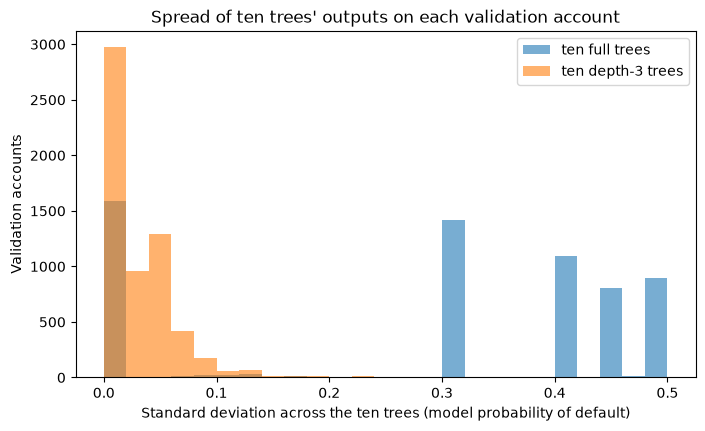

In [21]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4.5))
bins = np.linspace(0, 0.5, 26)
ax.hist(spread_full, bins=bins, alpha=0.6, label="ten full trees")
ax.hist(spread_3, bins=bins, alpha=0.6, label="ten depth-3 trees")
ax.set_title("Spread of ten trees' outputs on each validation account")
ax.set_xlabel("Standard deviation across the ten trees (model probability of default)")
ax.set_ylabel("Validation accounts")
ax.legend()
plt.show()

* The depth-3 trees pile up near zero: they mostly agree. The full trees spread out to 0.5, the largest standard deviation ten outputs of 0 and 1 can have (five of each).

## 1.7 Averaging the Ten Full Trees

Each full tree is unstable, but they are unstable in different directions: one tree's lucky split is another tree's missed one. Averaging their outputs keeps what they share and cancels part of what they do not.

Q. Average the ten full trees' outputs on each validation account. How does the average rank the accounts?

In [22]:
# the average of the ten trees' outputs on each account: one number per account
average_full = proba_ten.mean(axis=1)
average_3 = proba_ten_3.mean(axis=1)

print(f"average of the ten full trees: validation ROC AUC {roc_auc_score(y_valid, average_full):.4f}, "
      f"average precision {average_precision_score(y_valid, average_full):.4f}")
print(f"best of the ten full trees alone: validation ROC AUC {summary['validation ROC AUC'].max():.4f}")
print(f"average of the ten depth-3 trees: validation ROC AUC {roc_auc_score(y_valid, average_3):.4f}")
print(f"Course 4's pruned tree: validation ROC AUC {roc_auc_score(y_valid, score_valid):.4f}")

average of the ten full trees: validation ROC AUC 0.7243, average precision 0.4453
best of the ten full trees alone: validation ROC AUC 0.6219
average of the ten depth-3 trees: validation ROC AUC 0.7436
Course 4's pruned tree: validation ROC AUC 0.7627


* The average of ten full trees ranks the validation accounts at 0.7243, 0.1024 above the best of its own members (0.6219). No tree was changed; only their outputs were averaged. The average is the model probability of default in this file of the ten-tree model, and it takes 109 distinct values where one full tree takes almost only 0 and 1.
* Averaging the depth-3 trees gains far less (0.7436 against their best of 0.7330, 0.0106): they already agree, so there is little to cancel. **Averaging pays where the members disagree.** With only ten members, the depth-3 average still ranks the accounts higher than the full-tree average: the full trees start much lower and averaging has a long way to bring them.
* Neither ten-tree average reaches Course 4's pruned tree (0.7627). Day 2 builds the same average with scikit-learn's `BaggingClassifier` and measures how it changes from 10 trees to 100.

Q. Draw each model's validation ROC AUC on one line.

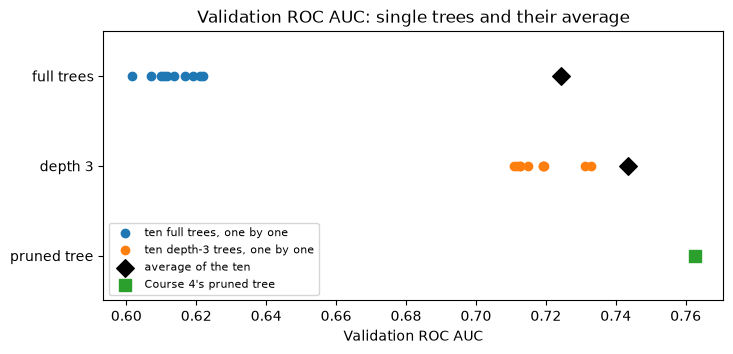

In [23]:
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.scatter(summary["validation ROC AUC"], [3] * 10, label="ten full trees, one by one")
ax.scatter(auc_3, [2] * 10, label="ten depth-3 trees, one by one")
ax.scatter([roc_auc_score(y_valid, average_full), roc_auc_score(y_valid, average_3)], [3, 2], marker="D", s=80,
           color="black", label="average of the ten")
ax.scatter([roc_auc_score(y_valid, score_valid)], [1], marker="s", s=80, label="Course 4's pruned tree")
ax.set_yticks([1, 2, 3])
ax.set_yticklabels(["pruned tree", "depth 3", "full trees"])
ax.set_ylim(0.5, 3.5)
ax.set_title("Validation ROC AUC: single trees and their average")
ax.set_xlabel("Validation ROC AUC")
ax.legend(loc="lower left", fontsize=8)
plt.show()

* The full trees' black diamond sits far to the right of its own dots; the depth-3 diamond moves only a little past its own. Averaging turned ten weak, disagreeing trees into a model above every one of them.

> **STORY: where the week's name comes from.** In August 1996 Leo Breiman published a paper titled "Bagging predictors" in *Machine Learning* (volume 24, issue 2, pages 123 to 140). Its title holds the name this week uses for what section 1.7 does by hand: fit the same kind of model to many bootstrap samples and average what they give.
>
> Source (read 2026-10-05): the Crossref record of the paper, https://api.crossref.org/works/10.1007/BF00058655, DOI https://doi.org/10.1007/BF00058655. Only the title, author, journal, volume, issue, pages, and date are taken from it; the paper itself was not read for this course.

## 1.8 The Out-of-Bag Rows

Each bootstrap sample left out about 36.8 percent of the training rows. The tree fitted on that sample never saw them, so they can score it, without touching the validation rows. They are the sample's **out-of-bag** rows. Day 2 uses them to score a whole bagged model; today, one function and one tree.

Q. Add `out_of_bag` to `ensemblekit.py`, and its two tests.

In [24]:
%%writefile -a ensemblekit.py


def out_of_bag(n_rows: int, drawn: np.ndarray) -> np.ndarray:
    """The positions a bootstrap sample never drew: its out-of-bag rows.

    Inputs: n_rows, how many rows the data has; drawn, the positions of a bootstrap sample.
    Output: the sorted positions from 0 to n_rows - 1 that are not in drawn.
    Convention: a model fitted on the drawn rows has never seen these rows, so they can score it.
    Raises ValueError if drawn is empty or holds a position outside 0 to n_rows - 1.
    """
    positions = np.asarray(drawn)
    if positions.size == 0:
        raise ValueError("drawn is empty")
    if positions.min() < 0 or positions.max() > n_rows - 1:
        raise ValueError(f"drawn holds a position outside 0 to {n_rows - 1}")
    # every position, minus the ones drawn at least once
    return np.setdiff1d(np.arange(n_rows), positions)

Appending to ensemblekit.py


In [25]:
%%writefile -a test_ensemblekit.py


def test_out_of_bag_hand():
    # rows 0 to 5; the sample drew 0, 0, 2, 5, 5, 5: rows 1, 3, 4 were never drawn
    left_out = ensemblekit.out_of_bag(6, np.array([0, 0, 2, 5, 5, 5]))
    assert left_out.tolist() == [1, 3, 4]
    with pytest.raises(ValueError):
        ensemblekit.out_of_bag(6, np.array([0, 6]))
    with pytest.raises(ValueError):
        ensemblekit.out_of_bag(6, np.array([], dtype=int))


def test_out_of_bag_share_near_e():
    n = 18_000
    drawn = ensemblekit.bootstrap_positions(n)
    left_out = ensemblekit.out_of_bag(n, drawn)
    # no row is both drawn and out of bag
    assert not set(left_out.tolist()) & set(drawn.tolist())
    # (1 - 1/n)^n tends to 1/e = 0.3679
    assert abs(len(left_out) / n - np.exp(-1)) < 0.01

Appending to test_ensemblekit.py


* The hand test uses six rows and a sample that drew 0, 0, 2, 5, 5, 5: rows 1, 3, and 4 were never drawn. The second test checks the share left out at n = 18,000 is within 0.01 of e^-1, and that no row is both drawn and out of bag.

Q. Reload the module and run all of today's tests.

In [26]:
importlib.reload(ensemblekit)
print(f"out_of_bag in ensemblekit: {hasattr(ensemblekit, 'out_of_bag')}")

out_of_bag in ensemblekit: True


In [27]:
# run the tests in the work folder with the kernel's own Python, in a fresh process
result = subprocess.run([sys.executable, "-m", "pytest", "-q", "-p", "no:cacheprovider", "test_ensemblekit.py"],
                        cwd=work, capture_output=True, text=True)
print(result.stdout + result.stderr)

.......                                                                  [100%]
7 passed in 1.51s



* `7 passed`: the module's three functions, tested.

Q. Which training rows did tree 1 never see, and how does it score on them?

In [28]:
# the training positions sample 1 never drew
left_out = ensemblekit.out_of_bag(n_rows, samples[0])
assert not set(left_out) & set(samples[0]), "a row is both drawn and out of bag"

# tree 1 scored on its own out-of-bag training rows, beside the validation rows
oob_proba = trees[0].predict_proba(X_train.iloc[left_out])[:, 1]
print(f"tree 1 never saw {len(left_out):,} of the {n_rows:,} training rows, {len(left_out) / n_rows:.2%}")
print(f"tree 1: ROC AUC {roc_auc_score(y_train.iloc[left_out], oob_proba):.4f} on its out-of-bag rows, "
      f"{summary.loc[1, 'validation ROC AUC']:.4f} on the validation rows")

tree 1 never saw 6,617 of the 18,000 training rows, 36.76%
tree 1: ROC AUC 0.6125 on its out-of-bag rows, 0.6219 on the validation rows


* Tree 1's out-of-bag rows are the 6,617 rows section 1.3 counted (sample 1 is that sample). On them it ranks at 0.6125, close to its 0.6219 on the validation rows: rows the tree never saw score it honestly, wherever they come from.
* Every bootstrap sample has its own out-of-bag rows, so every tree of a bagged model can be scored on rows it never saw. Day 2 turns that into a score for the whole model, and shows that scikit-learn's ready-made out-of-bag score measures something else by default.

## Excel Side by Side

Excel has no worksheet function for a bootstrap with a seed, and none for a decision tree. What Excel can do is the arithmetic around them: the share a bootstrap leaves out, counting a sample drawn in Python, and summarising ten trees' outputs pasted onto a sheet. Every formula below was typed into Excel by script (Excel 16.0 build 20430, 2026-10-05).

| Job | Python | Excel | Excel returned |
| --- | --- | --- | --- |
| Share left out at n = 18,000 | `(1 - 1 / n) ** n` | `=(1-1/n)^n` with n in a cell | 0.367869 |
| Share drawn at least once | `1 - (1 - 1 / n) ** n` | `=1-(1-1/n)^n` | 0.632131 |
| Times each position was drawn | `np.bincount(drawn)` | `=FREQUENCY(A2:A18001,SEQUENCE(18000,1,0))` in C2 (spills 18,001 cells) | equal to numpy |
| Rows drawn k times | `np.bincount(np.bincount(drawn))` | `=COUNTIF($C$2:$C$18001,k)` | 6,617, 6,662, 3,236, 1,150 for k = 0 to 3 |
| Rows never drawn | `n - len(np.unique(drawn))` | `=ROWS(A2:A18001)-COUNTA(UNIQUE(A2:A18001))` | 6,617 |
| Spread of ten trees on one account | `ten.std(axis=1, ddof=0)` | `=STDEV.P(B2:K2)`, filled down | equal to Python |
| Its average over the accounts | `spread_full.mean()` | `=AVERAGE(L2:L6001)` | 0.2858 |
| The ten trees' average | `proba_ten.mean(axis=1)` | `=AVERAGE(B2:K2)`, filled down | equal to Python |
| Share of accounts whose flag changes | `changes.mean()` | `=COUNTIF(B2:K2,">=0.5")` in N2 down, then `=COUNTIFS(N2:N6001,">0",N2:N6001,"<10")/ROWS(N2:N6001)` | 0.7325 |

**The positions come from Python.** `RAND`, `RANDBETWEEN`, and `RANDARRAY` take no seed, and Excel recalculates them: tested here, `=RAND()`, `=RANDBETWEEN(1,18000)`, and `=RANDARRAY(5)` all returned new numbers after one recalculation. A bootstrap drawn in Excel is a different sample every time the sheet recalculates, and no one can draw the same one again. So the sample is drawn in Python with `SEED`, and its 18,000 positions are pasted into column A as values.

**Counting the draws.** `FREQUENCY(A2:A18001, SEQUENCE(18000,1,0))` counts the positions falling at each of 0, 1, ..., 17999 (bins of whole numbers, so each count is one position's), and spills one count per position, plus one more cell for values above the last bin. `COUNTIF` on that column counts the positions drawn 0, 1, 2, ... times. `COUNTA(UNIQUE(...))` counts the distinct positions; subtracting from `ROWS(...)` gives the rows never drawn.

**The ten trees.** With the ten trees' validation outputs pasted into B2:K6001, one row per account, `STDEV.P` across a row is the spread numpy computes with `ddof=0`. `STDEV.S` divides by 9 instead of 10 (numpy's `ddof=1`, tested) and gives a larger number on every account whose ten outputs are not all equal, so the course uses `STDEV.P`. `COUNTIF(B2:K2,">=0.5")` counts the trees that flag the account; the account's flag changes when that count is above 0 and below 10.

Q. Do Excel's numbers equal Python's?

In [29]:
# Excel's numbers, from the course's Excel checks, beside Python's for the same rows
excel = {"(1 - 1/n)^n at n = 18,000": 0.36786922206143724,
         "rows never drawn by sample 1": 6617,
         "average spread of the ten full trees": 0.285845069563393,
         "share of accounts whose flag changes": 0.7325}
python = {"(1 - 1/n)^n at n = 18,000": share_left_out,
          "rows never drawn by sample 1": n_rows - len(distinct),
          "average spread of the ten full trees": spread_full.mean(),
          "share of accounts whose flag changes": changes.mean()}

side_by_side = pd.DataFrame({"Excel": excel, "Python": python})
side_by_side["within 1e-12"] = (side_by_side["Excel"] - side_by_side["Python"]).abs() < 1e-12
side_by_side

,Excel,Python,within 1e-12
"(1 - 1/n)^n at n = 18,000",0.367869,0.367869,True
rows never drawn by sample 1,6617.000000,6617.000000,True
average spread of the ten full trees,0.285845,0.285845,True
share of accounts whose flag changes,0.732500,0.732500,True


* Every number matches within 1e-12. Excel's `(1-1/n)^n` and Python's differ in the 13th decimal place, the last digits of two ways of raising a number to the power 18,000, so the comparison is printed as "within 1e-12" rather than as the gap itself.
* Excel's counts of rows drawn 0 to 6 times, 6,617, 6,662, 3,236, 1,150, 268, 58, 9, are numpy's.

## Save the Day with Git

The work folder gets its own repository, as in Course 4, and the first commit holds three files: Course 4's `mlkit.py`, unchanged, and the two new ones that import it. Committing `mlkit.py` beside them puts the dependency in the history: anyone who checks out this commit has everything `ensemblekit` needs.

Q. Make the work folder a repository.

In [30]:
# stop here, with the steps to install it, if Git is not on this machine
if shutil.which("git") is None:
    raise RuntimeError("Git is not installed. Install Git for Windows from https://git-scm.com/downloads "
                       "(or run  winget install --id Git.Git  where your firm allows it), restart VS Code, "
                       "and run this cell again. Colab has Git already.")

# -C "{work}" points every Git command at the work folder, whatever folder the notebook is in
!git -C "{work}" --version
# make the work folder a repository
!git -C "{work}" init -q -b main
# settings for this repository only: a course name, a reserved example email, line endings left as they are,
# and no commit signing, so a signing setup on your machine does not ask for a key here
!git -C "{work}" config user.name "Course Student"
!git -C "{work}" config user.email "student@example.com"
!git -C "{work}" config core.autocrlf false
!git -C "{work}" config commit.gpgsign false

git version 2.50.1.windows.1


Q. Is Git working in the work folder, and only there?

In [31]:
# the guard: Git must report the work folder as the top of this repository, or the notebook stops
top = subprocess.run(["git", "-C", str(work), "rev-parse", "--show-toplevel"],
                     capture_output=True, text=True, check=True).stdout.strip()
assert os.path.samefile(top, work), "Git is not working in the work folder. Stop, and run the setup cell again."
print(f"Git is working in {work.name} and nowhere else")

Git is working in pfi_course5_01_az141ygt and nowhere else


Q. Tell Git which files never to track: Python's bytecode cache, pytest's cache, and Excel workbooks.

In [32]:
%%writefile .gitignore
__pycache__/
.pytest_cache/
*.xlsx

Writing .gitignore


In [33]:
# ?? marks an untracked file; the card file is a copy and stays untracked
!git -C "{work}" status --short

?? .gitignore
?? credit_card_default.csv
?? ensemblekit.py
?? mlkit.py
?? test_ensemblekit.py


* The card file is a copy of the course's data, not today's work, so it is never committed.

Q. Commit `.gitignore`, Course 4's module, and the two new files.

In [34]:
!git -C "{work}" add .gitignore mlkit.py ensemblekit.py test_ensemblekit.py
!git -C "{work}" commit -q -m "Start ensemblekit beside Course 4's mlkit: card rows, bootstrap, out-of-bag rows, 7 tests"
!git -C "{work}" log --oneline
!git -C "{work}" show --stat --format=%s HEAD

592209d Start ensemblekit beside Course 4's mlkit: card rows, bootstrap, out-of-bag rows, 7 tests


Start ensemblekit beside Course 4's mlkit: card rows, bootstrap, out-of-bag rows, 7 tests

 .gitignore          |   3 +
 ensemblekit.py      |  86 ++++++++
 mlkit.py            | 568 ++++++++++++++++++++++++++++++++++++++++++++++++++++
 test_ensemblekit.py | 111 ++++++++++
 4 files changed, 768 insertions(+)


Q. Start the experiment log: write today's validation metrics to `results.csv`, with 4 decimals.

In [35]:
# one row per model: its name, the rows scored, its ranking metrics, and its flags at the threshold
rows = []
for name, output in [("course4_default_tree", default_tree.predict_proba(X_valid)[:, 1]),
                     ("course4_pruned_tree", score_valid),
                     ("average_of_ten_full_trees", average_full)]:
    metrics = mlkit.classification_metrics(y_valid, (output >= 0.5).astype(int))
    rows.append({"model": name, "rows": "validation", "roc_auc": roc_auc_score(y_valid, output),
                 "average_precision": average_precision_score(y_valid, output), "threshold": 0.5, **metrics})
results = pd.DataFrame(rows)
# 4 decimals and LF line endings, so tomorrow's diff shows a real change and prints the same everywhere
results.to_csv("results.csv", index=False, float_format="%.4f", lineterminator="\n")
print((work / "results.csv").read_text(encoding="utf-8"))
print(f"accuracy of flagging no account (all-zero baseline) on the validation rows: {1 - y_valid.mean():.4f}")

model,rows,roc_auc,average_precision,threshold,accuracy,precision,recall,f1
course4_default_tree,validation,0.6161,0.2917,0.5000,0.7278,0.3888,0.4032,0.3959
course4_pruned_tree,validation,0.7627,0.4954,0.5000,0.7683,0.4805,0.5840,0.5272
average_of_ten_full_trees,validation,0.7243,0.4453,0.5000,0.7907,0.5349,0.4099,0.4642

accuracy of flagging no account (all-zero baseline) on the validation rows: 0.7788


* Course 5's classification log has nine columns: `model, rows, roc_auc, average_precision, threshold, accuracy, precision, recall, f1`. `rows` says which rows were scored (`validation` here; `cv` when a later day scores by cross-validation). Today's threshold is 0.5 for every model, the flag a tree's own vote gives; from day 5 the threshold comes from out-of-fold probabilities on the training rows, by Course 4's recall rule.
* Accuracy is printed beside the all-zero baseline (0.7788) and never used to choose. Both of Course 4's trees score below the baseline on accuracy at 0.5 (0.7278 and 0.7683) and the ten-tree average above it (0.7907), yet the pruned tree ranks the accounts best by ROC AUC. Accuracy at one threshold says little about how a model ranks.

In [36]:
!git -C "{work}" add results.csv
!git -C "{work}" commit -q -m "Experiment log: validation metrics of Course 4's two trees and the average of ten bootstrap trees"
!git -C "{work}" log --oneline

1c90847 Experiment log: validation metrics of Course 4's two trees and the average of ten bootstrap trees


592209d Start ensemblekit beside Course 4's mlkit: card rows, bootstrap, out-of-bag rows, 7 tests


* Two commits: the code, then its results. Tomorrow's bagged model adds a row, and `git diff results.csv` will show it.

## Bring It Home

Start Course 5 in your own `my_bondmath` folder, beside `mlkit.py` from Course 4. Open a PowerShell terminal in VS Code.

**Step 1.** Install this course's packages into the course's `.venv`, once. The file adds XGBoost, LightGBM, imbalanced-learn, SHAP, and ipywidgets to Course 4's pins, and changes none of Course 4's versions.

```powershell
Set-Location "$HOME\projects\python-fixed-income"
.\.venv\Scripts\Activate.ps1
python -m pip install -r course5_advanced_ml\requirements.txt
```

**Step 2.** Go to your folder, check `mlkit.py` is there, copy in the card file today's tests read, and create the two files.

```powershell
Set-Location "$HOME\projects\my_bondmath"
Test-Path mlkit.py
Copy-Item "$HOME\projects\python-fixed-income\data\credit_card_default.csv" .
code ensemblekit.py
code test_ensemblekit.py
```

`Test-Path` prints `True`. If it prints `False`, finish Course 4's Bring It Home steps first, or write `mlkit.py` from this notebook's setup section.

**Step 3.** Paste the code of the three `%%writefile ensemblekit.py` cells (sections 1.1, 1.3, and 1.8), without their first lines, into `ensemblekit.py`, one after the other; do the same for the three `test_ensemblekit.py` cells. Save both.

**Step 4.** Run the new tests.

```powershell
python -m pytest -q test_ensemblekit.py
```

The last line says `7 passed`. Course 4's `test_mlkit.py` still passes as well, because nothing in `mlkit.py` changed.

**Step 5.** Commit the code only. The data file is a copy of the course's file, so it is never committed here.

```powershell
git status --short
git add ensemblekit.py test_ensemblekit.py
git commit -m "Start ensemblekit beside Course 4's mlkit: card rows, bootstrap, out-of-bag rows, 7 tests"
git log --oneline -3
```

**In Colab**, download `ensemblekit.py` and `test_ensemblekit.py` from the work folder under `/tmp` in the file browser.

## You Can Now

* Rebuild Course 4's card split with `course4_card_rows`, and say why Course 5 never scores Course 4's test rows.
* State a notebook's rows in one line: what fits, what reports, what stays closed.
* Draw a bootstrap sample with `bootstrap_positions` and say why about 36.8 percent of rows are left out.
* Show that a full tree's first question is stable while its leaves are not, and measure the instability one account at a time.
* Say what a depth limit buys and what it costs.
* Average trees fitted on bootstrap samples, and say why averaging helps full trees more than shallow ones.
* Find a sample's out-of-bag rows with `out_of_bag` and score a tree on them.
* Commit `mlkit.py` beside the module that imports it, and start Course 5's experiment log.

Tomorrow, day 2: bagging with scikit-learn, how many trees are enough, and the out-of-bag score, which is not what its name suggests.

## Exercises

The exercises use Course 4's card rows: fitted on the 18,000 training rows, scored on the 6,000 validation rows, the test rows closed. The four person columns are not features, and every answer describes this file. Replace each `...` with your own code, then run the check cell. Worked answers are in the solutions notebook in this folder.

Q. Run the next cell first. It loads the card rows, draws section 1.4's ten bootstrap samples, and defines `check`, a small function that marks your answers.

In [37]:
from sklearn.metrics import roc_auc_score
from sklearn.tree import DecisionTreeClassifier

# Course 4's training and validation rows of the card file
card = pd.read_csv("credit_card_default.csv")
X_train, X_valid, y_train, y_valid = ensemblekit.course4_card_rows(card)
n_rows = len(X_train)

# section 1.4's ten bootstrap samples: seeds SEED to SEED + 9
samples = [ensemblekit.bootstrap_positions(n_rows, seed=SEED + k) for k in range(10)]


def check(label, answer, expected):
    """Compare an exercise answer with the expected value and print the result."""
    if answer is ...:
        print(f"{label}: not attempted yet")
        return
    if isinstance(expected, float):
        # numbers with a decimal point: within a small tolerance
        correct = abs(answer - expected) < 1e-6
    else:
        correct = answer == expected
    if correct:
        print(f"{label}: correct")
    else:
        print(f"{label}: not yet. You have {answer}.")

### Exercise 1

Q. Repeat section 1.4's experiment with trees that keep at least 20 training rows in every leaf (`min_samples_leaf=20`, `random_state=SEED`), one on each of the ten samples. Store the average standard deviation of the ten outputs across the validation accounts (`ddof=0`) in **ex1_mean_sd**, and the validation ROC AUC of the ten trees' average output in **ex1_average_auc**.

In [38]:
ex1_mean_sd = ...
ex1_average_auc = ...

In [39]:
check("Exercise 1 the average spread", ex1_mean_sd, 0.15793474459793133)
check("Exercise 1 the average's ROC AUC", ex1_average_auc, 0.7682893003482786)

Exercise 1 the average spread: not attempted yet
Exercise 1 the average's ROC AUC: not attempted yet


### Exercise 2

Q. Draw one bootstrap sample with `ensemblekit.bootstrap_positions` (seed `SEED`) of 100 rows and one of 1,000,000 rows. Store the share of distinct rows in each in **ex2_share_100** and **ex2_share_million**.

In [40]:
ex2_share_100 = ...
ex2_share_million = ...

In [41]:
check("Exercise 2 the share at 100 rows", ex2_share_100, 0.66)
check("Exercise 2 the share at a million rows", ex2_share_million, 0.632241)

Exercise 2 the share at 100 rows: not attempted yet
Exercise 2 the share at a million rows: not attempted yet


### Exercise 3

Q. Add a function to your module. `distinct_share(positions, n_rows)` returns the share of the `n_rows` rows a sample drew at least once; it should call `out_of_bag` rather than count again, so it refuses the same bad inputs. Write the docstring first. Then add `test_distinct_share_hand`, which checks section 1.8's hand sample (0, 0, 2, 5, 5, 5 of six rows gives 0.5) and that an empty sample raises `ValueError`. Run pytest, reload the module, and store `ensemblekit.distinct_share(ensemblekit.bootstrap_positions(n_rows, seed=SEED), n_rows)` in **ex3_share**.

Write the function in the cell that starts with `%%writefile -a ensemblekit.py` and the test in the one that starts with `%%writefile -a test_ensemblekit.py`, and run each of those cells once.

In [42]:
%%writefile -a ensemblekit.py


# Exercise 3: write distinct_share(positions, n_rows) below this line

Appending to ensemblekit.py


In [43]:
%%writefile -a test_ensemblekit.py


# Exercise 3: write test_distinct_share_hand() below this line

Appending to test_ensemblekit.py


In [44]:
# run pytest, reload the module, then call your function
ex3_share = ...

In [45]:
check("Exercise 3 distinct_share on sample 1", ex3_share, 0.6323888888888889)

Exercise 3 distinct_share on sample 1: not attempted yet


### Exercise 4: AI check

You ask an AI assistant for a function that draws a bootstrap sample, and you give it a docstring as the request. **The docstring is the prompt.** This is what you gave it:

```
Draw one bootstrap sample of n_rows rows, seeded with SEED.

    Returns n_rows positions from 0 to n_rows - 1, drawn with replacement: some positions appear more than
    once, and about 36.8 percent of the rows are never drawn (the out-of-bag rows).
```

The function below came back. It was written for this course in the style of an AI assistant's answer. It runs without an error, returns 18,000 positions from 0 to 17,999 when asked for 18,000, and contains one bug.

In [46]:
# written for this course in the style of an AI assistant's answer. It runs, and it contains one bug.
def draw_bootstrap(n_rows):
    """Draw one bootstrap sample of n_rows rows, seeded with SEED.

    Returns n_rows positions from 0 to n_rows - 1, drawn with replacement: some positions appear more than
    once, and about 36.8 percent of the rows are never drawn (the out-of-bag rows).
    """
    rng = np.random.default_rng(SEED)
    # shuffle the row positions, so every row has the same chance of being picked
    return rng.permutation(n_rows)

Q. Before you run the next cell: how many of the 18,000 training rows will `draw_bootstrap(n_rows)` leave out of bag? The docstring says about 36.8 percent.

In [47]:
ai_drawn = draw_bootstrap(n_rows)
print(f"{len(ai_drawn):,} positions from {ai_drawn.min()} to {ai_drawn.max():,}")
print(f"distinct positions: {len(np.unique(ai_drawn)):,}; out of bag: {ensemblekit.out_of_bag(n_rows, ai_drawn).size:,}")

18,000 positions from 0 to 17,999
distinct positions: 18,000; out of bag: 0


Q. Test the function against its docstring before you trust it.

In [48]:
# the test, written from the docstring before the code is trusted
ai_drawn = draw_bootstrap(n_rows)
ai_left_out = ensemblekit.out_of_bag(n_rows, ai_drawn)

# 1. with replacement: fewer distinct positions than draws
assert len(np.unique(ai_drawn)) < len(ai_drawn), "every row was drawn exactly once: a shuffle, not a bootstrap"
# 2. some rows are out of bag
assert ai_left_out.size > 0, "no row is out of bag"
print(f"draw_bootstrap: {len(np.unique(ai_drawn)):,} distinct rows, {ai_left_out.size:,} out of bag")

AssertionError: every row was drawn exactly once: a shuffle, not a bootstrap

Q. Read the test's message, fix the function in the cell that defines it, and run that cell and the test again until the test passes. Then store the number of out-of-bag rows of the fixed function's sample, `ensemblekit.out_of_bag(n_rows, draw_bootstrap(n_rows)).size`, in **ex4_out_of_bag**.

In [49]:
# fix the function above and run the test again, then store the answer
ex4_out_of_bag = ...

In [50]:
check("Exercise 4 the fixed function's out-of-bag rows", ex4_out_of_bag, 6617)

Exercise 4 the fixed function's out-of-bag rows: not attempted yet


## Tidying Up

The work folder stays where it is, so you can open it: its name was printed by the setup cell, and on Windows it is under `$env:TEMP`. Every run of the setup cell makes a new one. To delete a work folder, run these lines in a cell of the same notebook session. Git marks its own files read-only, and on Windows a plain delete stops at them with a `PermissionError`, so the handler clears that flag and tries again.

```python
import stat

def clear_read_only(function, path, error):
    """Make a read-only file writable, then retry the delete that failed on it."""
    os.chmod(path, stat.S_IWRITE)
    function(path)

os.chdir(notebook_folder)
shutil.rmtree(work, onexc=clear_read_only)
print(f"{work.name} exists: {work.exists()}")
```